# Importação do .csv tratado

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('../../db/clean/bilheteria-distribuidoras.csv')
df.head()

# Análise Univariada

## Ingressos vendidos entre os anos de 2014 e 2025
Análise do público atingido por obras cinematográficas entre 2014 e 2025.

In [ ]:
publico = df['publico'].sum()
print(f'O público total entre 2014 e 2025 foi de {publico} pessoas')

Ou seja, mais de um bilhão e quinhentos milhões de ingressos de cinema foram vendidos durante esse período de tempo.

## Média de público

In [ ]:
media_publico = df['publico'].mean()
print(f'A média de público entre 2014 e 2025 foi de {int(media_publico)} pessoas')

In [ ]:
df.sort_values(by='publico', ascending=False)

# Análise Bivariada

## Análise de filmes distribuidos

In [ ]:
df['tipo_filme'] = df['cpb_roe'].apply(lambda x: 'Estrangeiro' if str(x).startswith('E') else 'Brasileiro')

In [ ]:
df['data_exibicao'] = pd.to_datetime(df['data_exibicao'])
df['ano'] = df['data_exibicao'].dt.year

### Salas de cinema para filmes brasileiros e estrangeiros

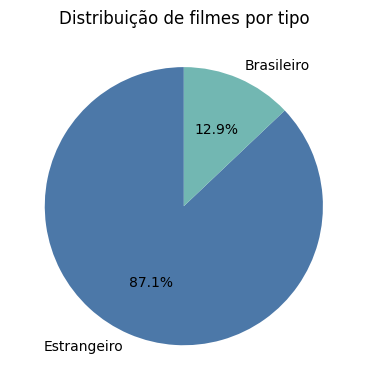

In [37]:
counts = df['tipo_filme'].value_counts()

plt.figure(figsize=(4,4))
counts.plot.pie(
  autopct='%1.1f%%',
  colors=['#4C78A8', '#72B7B2'],
  startangle=90,
  labels=counts.index
)
plt.ylabel('')
plt.title('Distribuição de filmes por tipo')
plt.tight_layout()
plt.show()

Nitidamente, percebemos que há uma grande discrepância entre a distribuição de filmes estrangeiros e nacionais, com uma grande predominância do cinema estrangeiro, que domina quase 90% das salas.

### Filmes únicos distribuidos por país

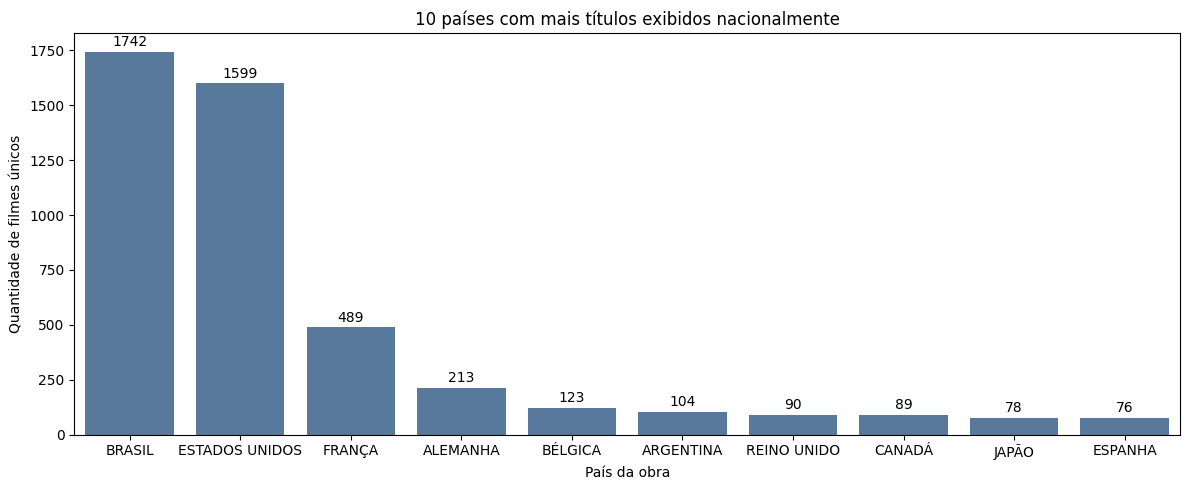

In [36]:
df_uni = (
    df.drop_duplicates(subset=['pais_obra', 'cpb_roe'])
)

# Top 10 países por quantidade
vc = df_uni['pais_obra'].value_counts().head(10)
top = vc.index

plt.figure(figsize=(12,5))
ax = sns.countplot(
    data=df_uni[df_uni['pais_obra'].isin(top)],
    x='pais_obra',
    order=top,
    color="#4C78A8"
)

ax.set_xlabel('País da obra')
ax.set_ylabel('Quantidade de filmes únicos')
ax.set_title('10 países com mais títulos exibidos nacionalmente')

ax.bar_label(ax.containers[0], labels=[f"{int(c)}" for c in vc.values], padding=2)

plt.xticks(rotation=0, ha='center')
plt.tight_layout()
plt.show()

Constatamos através do gráfico acima que a exibição de filmes nos cinemas nacionais está concentrado principalmente em filmes brasileiros e estadunidenses.
Percebemos um certo choque de informações ao comparar esse gráfico e o gráfico anterior, que mostra uma clara diferença favorecendo títulos do cinema estrangeiro em detrimento de obras nacionais. Uma hipótese imediata para isso é que, apesar de menos títulos, cada título estrangeiro possui, em média, mais salas de cinema para exibição do que os nacionais. Poderemos confirmar ou descartar essa hipótese baseando-se em outras análises com a ajuda de gráficos, coisa que será feita mais adiante.

### Filmes estrangeiros x brasileiros por ano

In [ ]:
reg_unicos = (
    df.drop_duplicates(subset=['ano', 'cpb_roe'])
)

contagem = (
    reg_unicos.groupby(['ano', 'tipo_filme'])
             .size()
             .reset_index(name='count')
)

anos_ord = sorted(contagem['ano'].unique())

plt.figure(figsize=(12,5))
ax = sns.barplot(
    data=contagem,
    x='ano',
    y='count',
    hue='tipo_filme',
    order=anos_ord,
    palette=['#72B7B2','#4C78A8']
)

ax.set_xlabel('Ano de produção')
ax.set_ylabel('Quantidade de filmes')
ax.set_title('Filmes brasileiros x estrangeiros distribuidos por ano')

# Rótulos com contagem absoluta
for container in ax.containers:
    ax.bar_label(container, fmt='%.0f', padding=2, fontsize=9)

plt.legend(title='Tipo de filme')
plt.tight_layout()
plt.show()

### Comparação relativa entre número de filmes e de salas para filmes nacionais e estrangeiros

### Público absoluto de filmes brasileiros e de filmes estrangeiros

In [ ]:
publico_total = df.groupby('tipo_filme')['publico'].sum()
print(publico_total)

In [ ]:
publico_por_ano = df.groupby(['ano', 'tipo_filme'])['publico'].sum().reset_index()

plt.figure(figsize=(12,5))
ax = sns.barplot(data=publico_por_ano, x='ano', y='publico', hue='tipo_filme', palette=['#4C78A8', '#72B7B2'])

ax.set_xlabel('Ano de exibição')
ax.set_ylabel('Público total (milhões)')
ax.set_title('Público absoluto por tipo de filme por ano')

# Rótulos no topo das barras em milhares
for container in ax.containers:
    ax.bar_label(container, labels=[f'{int(v.get_height()/1000)}K' for v in container], padding=2, fontsize=9)

plt.legend(title='Tipo de filme')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

In [ ]:
df['publico'].describe()

### Análise de títulos específicos

In [ ]:
df['titulo'].value_counts()